
# 🛰️ Lab 5: การจัดการข้อมูล Raster ด้วย Rasterio
## วิชา GE 234 Basic Programming for Geographers

### 🎯 **วัตถุประสงค์**
1. เรียนรู้การใช้ **Rasterio** ในการอ่านและแสดงผลข้อมูล Raster
2. สามารถเข้าถึงข้อมูลเมตาของไฟล์ Raster เช่น ค่า Resolution และ CRS (Coordinate Reference System)
3. ใช้ **Rasterio** ในการตัด (Clip), บันทึก (Save), และวิเคราะห์ข้อมูล Raster
4. คำนวณค่าดัชนีพืชพรรณ **NDVI (Normalized Difference Vegetation Index)** จากข้อมูล Raster

---

## 🔹 ตัวอย่างที่ 1: อ่านข้อมูล Raster ด้วย Rasterio


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import rasterio

# เปิดไฟล์ Raster ตัวอย่าง
raster_path = "/content/drive/MyDrive/GE234/pathum_thani.tif"  # ใส่ path ของไฟล์ .tif
with rasterio.open(raster_path) as dataset:
    print("ข้อมูลเมตาของภาพ Raster:")
    print(dataset.meta)

ข้อมูลเมตาของภาพ Raster:
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 6940, 'height': 4020, 'count': 4, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(8.983152841195215e-05, 0.0, 100.33373239859347,
       0.0, -8.983152841195215e-05, 14.273601043960312)}



## 🔹 ตัวอย่างที่ 2: แสดงผลข้อมูล Raster ด้วย Matplotlib


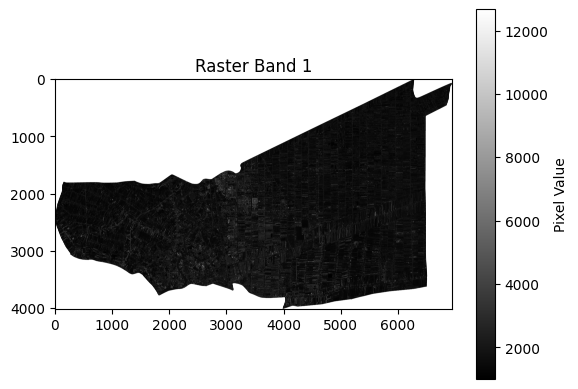

In [5]:

import matplotlib.pyplot as plt

# อ่านข้อมูลช่องสีน้ำเงิน (Band 1)
with rasterio.open(raster_path) as dataset:
    band1 = dataset.read(1)

# แสดงภาพ Raster
plt.imshow(band1, cmap="gray")
plt.colorbar(label="Pixel Value")
plt.title("Raster Band 1")
plt.show()



## 🔹 ตัวอย่างที่ 3: คำนวณค่า NDVI จากภาพ Raster


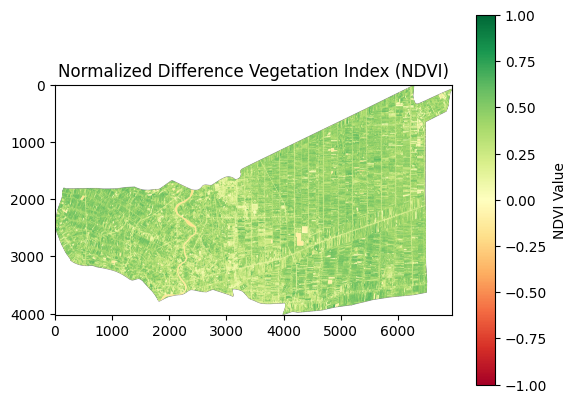

In [6]:

import numpy as np

# เปิดไฟล์ภาพดาวเทียม
with rasterio.open(raster_path) as dataset:
    nir = dataset.read(4).astype(float)  # ช่อง NIR (เช่น Band 4)
    red = dataset.read(3).astype(float)  # ช่อง Red (เช่น Band 3)

# คำนวณ NDVI
ndvi = (nir - red) / (nir + red + 1e-10)  # หลีกเลี่ยงการหารด้วยศูนย์

# แสดงผล NDVI
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI Value")
plt.title("Normalized Difference Vegetation Index (NDVI)")
plt.show()



## 🔹 ตัวอย่างที่ 4: บันทึก NDVI เป็นไฟล์ GeoTIFF


In [7]:

# บันทึกไฟล์ NDVI เป็น GeoTIFF
ndvi_output = "ndvi_output.tif"
with rasterio.open(raster_path) as src:
    profile = src.profile
    profile.update(dtype=rasterio.float32, count=1)

    with rasterio.open(ndvi_output, "w", **profile) as dst:
        dst.write(ndvi.astype(rasterio.float32), 1)

print("บันทึกไฟล์ NDVI เรียบร้อย!")


บันทึกไฟล์ NDVI เรียบร้อย!



## 🔹 ตัวอย่างที่ 5: ตัด (Clip) ข้อมูล Raster ตามขอบเขตที่กำหนด


In [8]:
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping

# โหลดไฟล์ Shapefile ของขอบเขตที่ต้องการตัด
shapefile_path = "/content/drive/MyDrive/Geo/TH_Province.shp"  # ใส่ path ของไฟล์ขอบเขต
gdf = gpd.read_file(shapefile_path)

# ตรวจสอบ CRS ของ Raster เพื่อใช้ในการแปลง Shapefile
with rasterio.open(raster_path) as src:
    raster_crs = src.crs

# แปลง CRS ของ GeoDataFrame ให้ตรงกับ Raster ถ้ายังไม่ตรงกัน
if gdf.crs != raster_crs:
    print(f"CRS เดิมของ Shapefile: {gdf.crs}")
    gdf = gdf.to_crs(raster_crs)
    print(f"CRS ใหม่ของ Shapefile หลังแปลง: {gdf.crs}")
else:
    print("CRS ของ Shapefile ตรงกับ Raster อยู่แล้ว ไม่ต้องทำการแปลง")

# แปลง Polygon เป็นรูปแบบ GeoJSON
geometry = [mapping(gdf.geometry[0])]

# ตัดภาพ Raster
with rasterio.open(raster_path) as src:
    out_image, out_transform = mask(src, geometry, crop=True)
    out_meta = src.meta.copy()

# อัปเดตเมตาดาต้าใหม่
out_meta.update({"height": out_image.shape[1], "width": out_image.shape[2], "transform": out_transform, "crs": raster_crs})

# บันทึกไฟล์ที่ถูกตัด
clipped_raster = "clipped_output.tif"
with rasterio.open(clipped_raster, "w", **out_meta) as dest:
    dest.write(out_image)

print("ตัดข้อมูล Raster สำเร็จ!")

CRS เดิมของ Shapefile: EPSG:32647
CRS ใหม่ของ Shapefile หลังแปลง: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
ตัดข้อมูล Raster สำเร็จ!


In [9]:
print("\n--- ตรวจสอบระบบพิกัด (CRS) ---")

# ตรวจสอบ CRS ของ Raster
with rasterio.open(raster_path) as src:
    raster_crs = src.crs
    print(f"CRS ของ Raster: {raster_crs}")

# ตรวจสอบ CRS ของ Shapefile
# โหลดไฟล์ Shapefile อีกครั้งเพื่อเข้าถึง CRS
gdf = gpd.read_file(shapefile_path)
shapefile_crs = gdf.crs
print(f"CRS ของ Shapefile: {shapefile_crs}")

# เปรียบเทียบ CRS
if raster_crs == shapefile_crs:
    print("CRS ของ Raster และ Shapefile ตรงกัน!")
else:
    print("CRS ของ Raster และ Shapefile ไม่ตรงกัน. อาจเป็นสาเหตุหนึ่งที่ทำให้เกิดปัญหาการทับซ้อน")
    print("อาจจำเป็นต้องแปลง CRS ของไฟล์ใดไฟล์หนึ่งให้ตรงกันก่อนทำการตัด")


--- ตรวจสอบระบบพิกัด (CRS) ---
CRS ของ Raster: EPSG:4326
CRS ของ Shapefile: EPSG:32647
CRS ของ Raster และ Shapefile ไม่ตรงกัน. อาจเป็นสาเหตุหนึ่งที่ทำให้เกิดปัญหาการทับซ้อน
อาจจำเป็นต้องแปลง CRS ของไฟล์ใดไฟล์หนึ่งให้ตรงกันก่อนทำการตัด


## 🔹 ตัวอย่างที่ 6: แปลงระบบพิกัด (CRS) ของ Shapefile
เนื่องจาก CRS ของ Raster และ Shapefile ไม่ตรงกัน เราจำเป็นต้องแปลง CRS ของ Shapefile ให้เป็น `EPSG:4326` เพื่อให้สามารถทำงานร่วมกันได้อย่างถูกต้อง

In [10]:
# ตรวจสอบว่า CRS ของ GeoDataFrame ยังไม่ใช่ EPSG:4326
if gdf.crs != 'EPSG:4326':
    print(f"CRS เดิมของ Shapefile: {gdf.crs}")
    # แปลง CRS ของ GeoDataFrame ให้เป็น EPSG:4326
    gdf = gdf.to_crs(epsg=4326)
    print(f"CRS ใหม่ของ Shapefile หลังแปลง: {gdf.crs}")
else:
    print("CRS ของ Shapefile เป็น EPSG:4326 อยู่แล้ว ไม่ต้องทำการแปลง")

# อัปเดต geometry ให้ใช้ CRS ที่แปลงแล้ว
geometry = [mapping(gdf.geometry[0])]

print("แปลง CRS ของ Shapefile เรียบร้อยแล้ว!")

CRS เดิมของ Shapefile: EPSG:32647
CRS ใหม่ของ Shapefile หลังแปลง: EPSG:4326
แปลง CRS ของ Shapefile เรียบร้อยแล้ว!



# 📝 **กิจกรรมในแลป**

1. **แบบฝึกหัด 1**: ใช้ **Rasterio** อ่านข้อมูลภาพ **Raster** และแสดงผลด้วย Matplotlib  
2. **แบบฝึกหัด 2**: ดึงข้อมูลเมตาของไฟล์ Raster และอธิบายค่าต่าง ๆ ที่ได้  
3. **แบบฝึกหัด 3**: ใช้ **NumPy และ Rasterio** คำนวณค่า NDVI และแสดงผลแผนที่  
4. **แบบฝึกหัด 4**: ใช้ **Rasterio** ตัดข้อมูลภาพจากขอบเขตที่กำหนดในไฟล์ Shapefile  


# **แบบฝึกหัด 1: ใช้ Rasterio อ่านข้อมูลภาพ Raster และแสดงผลด้วย Matplotlib**

**Data Access**: เชื่อมต่อและดึงข้อมูลจากไฟล์ GeoTIFF โดยใช้ rasterio

**Data Extraction**: อ่านค่าจากช่องสัญญาณ (Band) ของดาวเทียมเพื่อนำมาวิเคราะห์

**Visualization**: แสดงผลเชิงภาพและแถบค่าข้อมูล (Colorbar) เพื่อตรวจสอบลักษณะการสะท้อนแสงหรือค่าทางสถิติของพื้นที่ศึกษา

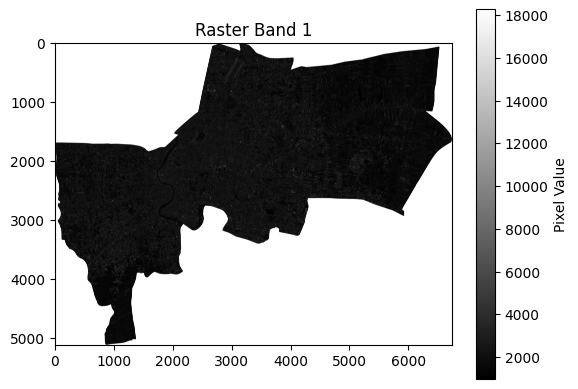

In [11]:
import rasterio
import matplotlib.pyplot as plt

# กำหนด path ของไฟล์ Raster
raster_path = "/content/drive/MyDrive/GE234/bangkok.tif"

# เปิดไฟล์ Raster และอ่านข้อมูลช่องสีน้ำเงิน (Band 1)
with rasterio.open(raster_path) as dataset:
    band1 = dataset.read(1)

# แสดงภาพ Raster
plt.imshow(band1, cmap="gray")
plt.colorbar(label="Pixel Value")
plt.title("Raster Band 1")
plt.show()

# **แบบฝึกหัด 2: ดึงข้อมูลเมตาของไฟล์ Raster และอธิบายค่าต่าง ๆ ที่ได้**

**โค้ดนี้ทำหน้าที่ "ตรวจสอบคุณสมบัติทางเทคนิค (Metadata)" ของไฟล์ Raster ครับ ถ้าภาพแรกคือการ "ดูภาพ" ภาพนี้คือการ "ดูรายละเอียดเชิงลึก" เพื่อให้รู้ว่าไฟล์นี้มีโครงสร้างอย่างไร ก่อนจะนำไปวิเคราะห์ต่อ**

โค้ดนี้ใช้ dataset.meta เพื่อดึง "ข้อมูลที่อธิบายตัวข้อมูลเอง" ซึ่งมีความสำคัญมากในงาน GIS:

**Driver ('GTiff')**: ระบุว่าไฟล์นี้เป็นรูปแบบ GeoTIFF ซึ่งรองรับข้อมูลพิกัดทางภูมิศาสตร์

**DataType ('float64')**: บอกความละเอียดของข้อมูลในแต่ละพิกเซล ว่าเก็บข้อมูลแบบตัวเลขทศนิยมละเอียดสูง (เหมาะสำหรับงานวิเคราะห์ที่ต้องการความแม่นยำ)

**Dimensions (Width: 6735, Height: 5123)**: ขนาดของภาพในหน่วยพิกเซล (ไฟล์นี้มีพิกเซลรวมกันกว่า 34 ล้านจุด!)

**Count (4)**: จำนวน "ชั้น" ข้อมูล หรือ Band ในที่นี้มี 4 Band (เช่น อาจเป็น R, G, B และ Near-Infrared)

**CRS (EPSG:4326)**: หัวใจสำคัญของงานแผนที่ คือระบบพิกัดแบบ WGS 84 (ละติจูด/ลองจิจูด) ทำให้รู้ว่าพิกเซลนี้อยู่ที่ไหนบนโลก

**Transform (Affine Transform)**: เมทริกซ์ที่ทำหน้าที่ "ตรึงภาพ" เข้ากับพิกัดบนพื้นโลก บอกว่าพิกเซลแต่ละพิกเซลมีขนาดเท่าไหร่ (Resolution) และจุดเริ่มต้นของภาพอยู่ที่พิกัดใด

In [12]:
import rasterio

# กำหนด path ของไฟล์ Raster ที่ต้องการตรวจสอบ (ใช้ไฟล์เดียวกับแบบฝึกหัด 1)
raster_path_ex2 = "/content/drive/MyDrive/GE234/bangkok.tif"

# เปิดไฟล์ Raster และเข้าถึงข้อมูลเมตา
with rasterio.open(raster_path_ex2) as dataset:
    print("\n--- ข้อมูลเมตาของภาพ Raster (แบบฝึกหัด 2) ---")
    print(dataset.meta)

    print("\n--- คำอธิบายค่าเมตาที่สำคัญ ---")
    print(f"Driver: {dataset.driver} - รูปแบบไฟล์ (เช่น GeoTIFF)")
    print(f"DataType: {dataset.meta['dtype']} - ประเภทข้อมูลของพิกเซล (เช่น float64, uint8)")
    print(f"NoData Value: {dataset.nodata} - ค่าที่ใช้ระบุว่าไม่มีข้อมูลในพิกเซลนั้นๆ (อาจเป็น None ถ้าไม่มีกำหนด)")
    print(f"Width: {dataset.width} - จำนวนคอลัมน์ของพิกเซลในภาพ")
    print(f"Height: {dataset.height} - จำนวนแถวของพิกเซลในภาพ")
    print(f"Count: {dataset.count} - จำนวน Band หรือช่องสัญญาณของภาพ (เช่น RGB มี 3, ภาพดาวเทียมอาจมีมากกว่า)")
    print(f"CRS: {dataset.crs} - ระบบพิกัดทางภูมิศาสตร์ของภาพ (Coordinate Reference System)")
    print(f"Transform: {dataset.transform} - Affine Transform ที่ใช้อธิบายตำแหน่งและขนาดของพิกเซลในระบบพิกัด")


--- ข้อมูลเมตาของภาพ Raster (แบบฝึกหัด 2) ---
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 6735, 'height': 5123, 'count': 4, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(8.983152841195215e-05, 0.0, 100.3315764419116,
       0.0, -8.983152841195215e-05, 13.95317198211488)}

--- คำอธิบายค่าเมตาที่สำคัญ ---
Driver: GTiff - รูปแบบไฟล์ (เช่น GeoTIFF)
DataType: float64 - ประเภทข้อมูลของพิกเซล (เช่น float64, uint8)
NoData Value: None - ค่าที่ใช้ระบุว่าไม่มีข้อมูลในพิกเซลนั้นๆ (อาจเป็น None ถ้าไม่มีกำหนด)
Width: 6735 - จำนวนคอลัมน์ของพิกเซลในภาพ
Height: 5123 - จำนวนแถวของพิกเซลในภาพ
Count: 4 - จำนวน Band หรือช่องสัญญาณของภาพ (เช่น RGB มี 3, ภาพดาวเทียมอาจมีมากกว่า)
CRS: EPSG:4

# **แบบฝึกหัด 3: ใช้ NumPy และ Rasterio คำนวณค่า NDVI และแสดงผลแผนที่**

**NDVI (Normalized Difference Vegetation Index)** เป็นดัชนีที่ใช้บอกความหนาแน่นของพืชพรรณ โดยอาศัยการคำนวณจากค่าการสะท้อนแสงในย่าน Near-Infrared (NIR) และ Red Band การคำนวณ NDVI จะทำให้เราสามารถวิเคราะห์สุขภาพและความหนาแน่นของพืชพรรณได้

$$NDVI = (NIR - Red) / (NIR + Red)$$

*   **NIR (Near-Infrared)**: ย่านแสงใกล้อินฟราเรด ซึ่งพืชพรรณที่แข็งแรงจะสะท้อนแสงในย่านนี้สูง
*   **Red**: ย่านแสงสีแดง ซึ่งพืชพรรณจะดูดกลืนแสงในย่านนี้เพื่อใช้ในการสังเคราะห์แสง

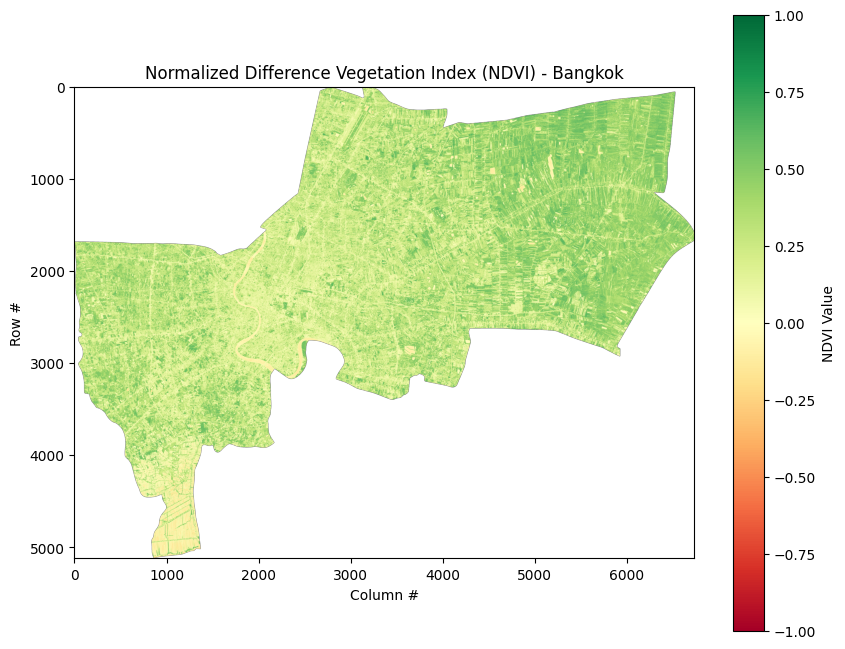

In [13]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

# กำหนด path ของไฟล์ภาพดาวเทียม
# โปรดตรวจสอบว่าไฟล์ bangkok.tif อยู่ในพาธที่ถูกต้องนี้
raster_path_ex3 = "/content/drive/MyDrive/GE234/bangkok.tif"

# เปิดไฟล์ภาพดาวเทียมและอ่านค่า Band ที่ต้องการ
with rasterio.open(raster_path_ex3) as dataset:
    # โดยทั่วไป: Band 4 คือ NIR, Band 3 คือ Red (สำหรับภาพดาวเทียมหลายชนิด)
    nir = dataset.read(4).astype(float)  # ช่อง NIR
    red = dataset.read(3).astype(float)  # ช่อง Red

# คำนวณ NDVI
# หลีกเลี่ยงการหารด้วยศูนย์โดยการเพิ่มค่าเล็กน้อย (1e-10) ในตัวส่วน
ndvi = (nir - red) / (nir + red + 1e-10)

# แสดงผล NDVI
plt.figure(figsize=(10, 8))
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1) # ใช้ cmap "RdYlGn" เพื่อแสดงค่า NDVI (แดง-พืชพรรณน้อย, เขียว-พืชพรรณมาก)
plt.colorbar(label="NDVI Value")
plt.title("Normalized Difference Vegetation Index (NDVI) - Bangkok")
plt.xlabel("Column #")
plt.ylabel("Row #")
plt.show()

# **แบบฝึกหัด 4: ใช้ Rasterio ตัดข้อมูลภาพจากขอบเขตที่กำหนดในไฟล์ Shapefile**

การตัด (Clipping) ข้อมูล Raster ด้วยขอบเขตจาก Shapefile เป็นขั้นตอนสำคัญในการวิเคราะห์ข้อมูลทางภูมิสารสนเทศ เพื่อจำกัดพื้นที่ศึกษาให้เหลือเฉพาะส่วนที่ต้องการ โดยในแบบฝึกหัดนี้เราจะใช้ไฟล์ `bangkok.tif` และ `TH_Province.shp` ในการดำเนินการ

In [14]:
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping
import rasterio

# กำหนด path ของไฟล์ Raster และ Shapefile ที่ต้องการใช้
# โปรดตรวจสอบว่าไฟล์ bangkok.tif และ TH_Province.shp อยู่ในพาธที่ถูกต้องนี้
raster_path_ex4 = "/content/drive/MyDrive/GE234/bangkok.tif"
shapefile_path_ex4 = "/content/drive/MyDrive/Geo/TH_Province.shp"

# โหลดไฟล์ Shapefile ของขอบเขตที่ต้องการตัด
gdf_ex4 = gpd.read_file(shapefile_path_ex4)

# ตรวจสอบ CRS ของ Raster เพื่อใช้ในการแปลง Shapefile
with rasterio.open(raster_path_ex4) as src:
    raster_crs_ex4 = src.crs
    print(f"CRS ของ Raster: {raster_crs_ex4}")

# แปลง CRS ของ GeoDataFrame ให้ตรงกับ Raster ถ้ายังไม่ตรงกัน
if gdf_ex4.crs != raster_crs_ex4:
    print(f"CRS เดิมของ Shapefile: {gdf_ex4.crs}")
    gdf_ex4 = gdf_ex4.to_crs(raster_crs_ex4)
    print(f"CRS ใหม่ของ Shapefile หลังแปลง: {gdf_ex4.crs}")
else:
    print("CRS ของ Shapefile ตรงกับ Raster อยู่แล้ว ไม่ต้องทำการแปลง")

# แปลง Polygon เป็นรูปแบบ GeoJSON เพื่อใช้ในการตัด
# ใช้ .iloc[0] เพื่อเลือก Polygon แรกใน GeoDataFrame สำหรับการตัด (ถ้า Shapefile มีหลายฟีเจอร์)
geometry_ex4 = [mapping(gdf_ex4.geometry.iloc[0])]

# ตัดภาพ Raster
with rasterio.open(raster_path_ex4) as src:
    out_image_ex4, out_transform_ex4 = mask(src, geometry_ex4, crop=True)
    out_meta_ex4 = src.meta.copy()

# อัปเดตเมตาดาต้าใหม่สำหรับภาพที่ถูกตัด
out_meta_ex4.update({
    "height": out_image_ex4.shape[1],
    "width": out_image_ex4.shape[2],
    "transform": out_transform_ex4,
    "crs": raster_crs_ex4
})

# บันทึกไฟล์ที่ถูกตัด
clipped_raster_output = "clipped_bangkok_by_province.tif"
with rasterio.open(clipped_raster_output, "w", **out_meta_ex4) as dest:
    dest.write(out_image_ex4)

print(f"ตัดข้อมูล Raster สำเร็จ! ไฟล์ถูกบันทึกที่: {clipped_raster_output}")

CRS ของ Raster: EPSG:4326
CRS เดิมของ Shapefile: EPSG:32647
CRS ใหม่ของ Shapefile หลังแปลง: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
ตัดข้อมูล Raster สำเร็จ! ไฟล์ถูกบันทึกที่: clipped_bangkok_by_province.tif
